In [1]:
# подлючение библиотек для обработки датасета
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import make_scorer,mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import TimeSeriesSplit, train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from xgboost import XGBRegressor, plot_tree

In [2]:
!gdown --id 1qozRwXEWK4lQiAF1iqmNgeDoYO3GKKAh

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1qozRwXEWK4lQiAF1iqmNgeDoYO3GKKAh
To: /content/crop_yield_dataset.csv
100% 4.74M/4.74M [00:00<00:00, 132MB/s]


In [3]:
dataset = pd.read_csv('crop_yield_dataset.csv')

In [4]:
# просмотр данных
print(dataset)

             Date  Crop_Type Soil_Type  Soil_pH  Temperature   Humidity  \
0      2014-01-01      Wheat     Peaty     5.50     9.440599  80.000000   
1      2014-01-01       Corn     Loamy     6.50    20.052576  79.947424   
2      2014-01-01       Rice     Peaty     5.50    12.143099  80.000000   
3      2014-01-01     Barley     Sandy     6.75    19.751848  80.000000   
4      2014-01-01    Soybean     Peaty     5.50    16.110395  80.000000   
...           ...        ...       ...      ...          ...        ...   
36515  2023-12-31     Cotton      Clay     6.25    19.538555  80.000000   
36516  2023-12-31  Sugarcane     Peaty     5.50    21.068336  78.931664   
36517  2023-12-31     Tomato     Sandy     6.75     6.030148  80.000000   
36518  2023-12-31     Potato     Peaty     5.50    11.079561  80.000000   
36519  2023-12-31  Sunflower      Clay     6.25    11.455692  80.000000   

       Wind_Speed     N     P     K  Crop_Yield  Soil_Quality  
0       10.956707  60.5  45.0  31.5

In [5]:
dataset.shape

(36520, 12)

In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36520 entries, 0 to 36519
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          36520 non-null  object 
 1   Crop_Type     36520 non-null  object 
 2   Soil_Type     36520 non-null  object 
 3   Soil_pH       36520 non-null  float64
 4   Temperature   36520 non-null  float64
 5   Humidity      36520 non-null  float64
 6   Wind_Speed    36520 non-null  float64
 7   N             36520 non-null  float64
 8   P             36520 non-null  float64
 9   K             36520 non-null  float64
 10  Crop_Yield    36520 non-null  float64
 11  Soil_Quality  36520 non-null  float64
dtypes: float64(9), object(3)
memory usage: 3.3+ MB


In [7]:
sum(dataset.duplicated())

0

In [8]:
dataset.describe()

,Soil_pH,Temperature,Humidity,Wind_Speed,N,P,K,Crop_Yield,Soil_Quality
count,36520.000000,36520.000000,36520.000000,36520.000000,36520.000000,36520.000000,36520.00000,36520.000000,36520.000000
mean,6.602731,23.813996,74.256624,10.020153,66.011035,53.014006,42.01825,26.878480,37.516632
std,0.816973,8.920519,6.767587,2.998310,10.886721,8.812884,8.53781,25.740936,17.703171
min,5.500000,-3.540176,45.851089,-3.388906,45.000000,36.000000,27.00000,0.000000,13.291667
25%,6.250000,17.168542,69.745252,7.985872,58.500000,45.000000,35.00000,0.000000,22.500000
50%,6.500000,22.902987,77.097013,10.000299,65.000000,54.000000,42.00000,23.366344,35.583333
75%,6.750000,30.254748,80.000000,12.038546,71.500000,60.000000,49.50000,46.415729,49.291667
max,8.000000,54.148911,80.000000,22.606078,91.000000,72.000000,60.00000,136.711982,74.333333


In [9]:
print(dataset[dataset["Wind_Speed"] < 0])

             Date  Crop_Type Soil_Type  Soil_pH  Temperature   Humidity  \
1903   2014-07-10     Barley      Clay     6.25    28.392221  71.607779   
2964   2014-10-24    Soybean      Clay     6.25    17.502972  80.000000   
3067   2014-11-03     Tomato      Clay     6.25    15.166904  80.000000   
4839   2015-04-29  Sunflower     Sandy     6.75    28.229371  71.770629   
5007   2015-05-16     Tomato     Peaty     5.50    19.456907  80.000000   
9236   2016-07-12  Sugarcane     Peaty     5.50    41.585447  58.414553   
10485  2016-11-14     Cotton    Saline     8.00    23.513040  76.486960   
11034  2017-01-08    Soybean    Saline     8.00    14.137965  80.000000   
11866  2017-04-01  Sugarcane     Sandy     6.75    23.971809  76.028191   
14954  2018-02-04    Soybean    Saline     8.00    10.258233  80.000000   
20757  2019-09-07     Tomato      Clay     6.25    17.176058  80.000000   
22228  2020-02-01     Potato      Clay     6.25    22.804531  77.195469   
22256  2020-02-04  Sugarc

In [10]:
dataset.loc[dataset["Wind_Speed"] < 0, "Wind_Speed"] = np.nan
dataset['Wind_Speed'] = dataset['Wind_Speed'].interpolate(method='linear')

In [11]:
dataset.describe(include=['object'])
# просмотр данных о столбцах типа object

,Date,Crop_Type,Soil_Type
count,36520,36520,36520
unique,3652,10,5
top,2014-01-01,Wheat,Saline
freq,10,3652,7361


In [12]:
# т.к. данные не имеют естественного порядка следования, используется One-Hot Encoding
dataset = pd.concat([dataset, pd.get_dummies(dataset.Soil_Type, prefix='S-T', drop_first=True)], axis=1)
# удаление исходного столбца
dataset.drop('Soil_Type', axis=1, inplace=True)

In [13]:
# т.к. данные не имеют естественного порядка следования, используется One-Hot Encoding
dataset = pd.concat([dataset, pd.get_dummies(dataset.Crop_Type, prefix='C-T', drop_first=True)], axis=1)
# удаление исходного столбца
dataset.drop('Crop_Type', axis=1, inplace=True)

In [14]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36520 entries, 0 to 36519
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           36520 non-null  object 
 1   Soil_pH        36520 non-null  float64
 2   Temperature    36520 non-null  float64
 3   Humidity       36520 non-null  float64
 4   Wind_Speed     36520 non-null  float64
 5   N              36520 non-null  float64
 6   P              36520 non-null  float64
 7   K              36520 non-null  float64
 8   Crop_Yield     36520 non-null  float64
 9   Soil_Quality   36520 non-null  float64
 10  S-T_Loamy      36520 non-null  bool   
 11  S-T_Peaty      36520 non-null  bool   
 12  S-T_Saline     36520 non-null  bool   
 13  S-T_Sandy      36520 non-null  bool   
 14  C-T_Corn       36520 non-null  bool   
 15  C-T_Cotton     36520 non-null  bool   
 16  C-T_Potato     36520 non-null  bool   
 17  C-T_Rice       36520 non-null  bool   
 18  C-T_So

In [15]:
# преобразуем столбец Date к типу date
dataset['Date'] = pd.to_datetime(dataset['Date'])

In [16]:
dataset.set_index('Date', inplace=True)

In [17]:
dataset.head()

,Soil_pH,Temperature,Humidity,Wind_Speed,N,P,K,Crop_Yield,Soil_Quality,S-T_Loamy,...,S-T_Sandy,C-T_Corn,C-T_Cotton,C-T_Potato,C-T_Rice,C-T_Soybean,C-T_Sugarcane,C-T_Sunflower,C-T_Tomato,C-T_Wheat
Date,,,,,,,,,,,,,,,,,,,,,
2014-01-01,5.50,9.440599,80.000000,10.956707,60.5,45.0,31.5,0.000000,22.833333,False,...,False,False,False,False,False,False,False,False,False,True
2014-01-01,6.50,20.052576,79.947424,8.591577,84.0,66.0,50.0,104.871310,66.666667,True,...,False,True,False,False,False,False,False,False,False,False
2014-01-01,5.50,12.143099,80.000000,7.227751,71.5,54.0,38.5,0.000000,27.333333,False,...,False,False,False,False,True,False,False,False,False,False
2014-01-01,6.75,19.751848,80.000000,2.682683,50.0,40.0,30.0,58.939796,35.000000,False,...,True,False,False,False,False,False,False,False,False,False
2014-01-01,5.50,16.110395,80.000000,7.696070,49.5,45.0,38.5,32.970413,22.166667,False,...,False,False,False,False,False,True,False,False,False,False


In [18]:
dataset.corr()

,Soil_pH,Temperature,Humidity,Wind_Speed,N,P,K,Crop_Yield,Soil_Quality,S-T_Loamy,...,S-T_Sandy,C-T_Corn,C-T_Cotton,C-T_Potato,C-T_Rice,C-T_Soybean,C-T_Sugarcane,C-T_Sunflower,C-T_Tomato,C-T_Wheat
Soil_pH,1.000000,0.009911,-0.009051,0.002985,0.248713,0.295893,0.304062,-0.016397,-0.324216,-0.062788,...,0.089985,0.003500,0.003751,-0.000299,-0.003120,0.003975,0.001014,-0.002869,0.001908,-0.001667
Temperature,0.009911,1.000000,-0.942212,0.002399,0.000896,0.001060,0.002090,-0.288140,-0.006447,0.001730,...,0.001006,-0.002243,-0.001750,0.004843,-0.001219,-0.001653,0.000143,0.000185,0.003527,-0.001916
Humidity,-0.009051,-0.942212,1.000000,-0.004913,-0.001425,-0.001529,-0.002154,0.511841,0.006123,-0.001213,...,-0.000103,-0.000915,0.000802,-0.002219,0.002064,0.003480,0.000155,-0.000294,-0.002331,0.001537
Wind_Speed,0.002985,0.002399,-0.004913,1.000000,-0.005451,-0.002051,-0.001843,-0.008635,-0.006326,-0.002378,...,0.000018,-0.004845,-0.007290,0.002953,0.000858,0.002169,-0.004442,0.007681,-0.002114,-0.003510
N,0.248713,0.000896,-0.001425,-0.005451,1.000000,0.892132,0.700894,0.143744,0.356389,0.496391,...,-0.508891,0.185387,0.005657,-0.003796,0.362945,-0.367197,0.370466,-0.182248,-0.185224,-0.004119
P,0.295893,0.001060,-0.001529,-0.002051,0.892132,1.000000,0.906531,0.166614,0.386558,0.597927,...,-0.605010,0.077397,0.082523,-0.117885,0.259515,-0.113225,0.268091,0.077568,-0.304426,-0.118248
K,0.304062,0.002090,-0.002154,-0.001843,0.700894,0.906531,1.000000,0.155379,0.361704,0.615177,...,-0.618418,-0.076659,0.241882,-0.238576,0.072904,0.078255,0.237520,0.079901,-0.080294,-0.238913
Crop_Yield,-0.016397,-0.288140,0.511841,-0.008635,0.143744,0.166614,0.155379,1.000000,0.197472,0.187086,...,-0.071346,0.018804,0.030176,-0.008613,0.023436,-0.012256,0.023522,0.008029,-0.052890,-0.013040
Soil_Quality,-0.324216,-0.006447,0.006123,-0.006326,0.356389,0.386558,0.361704,0.197472,1.000000,0.755790,...,0.000483,0.026162,0.038373,-0.048224,0.087116,-0.061301,0.103045,-0.001592,-0.068189,-0.038987
S-T_Loamy,-0.062788,0.001730,-0.001213,-0.002378,0.496391,0.597927,0.615177,0.187086,0.755790,1.000000,...,-0.249252,0.002101,0.005983,-0.009089,-0.009546,-0.001553,-0.003608,0.006897,-0.002238,-0.002695


In [19]:
dataset2=dataset.copy()

In [20]:
y=dataset2.pop('Crop_Yield')
#присваиваем y целевой признак, удаляем его из датасета

In [21]:
x=dataset2
#присваиваем датасет x

In [22]:
# Определение размера обучающей и валидационной выборки
train_size = int(len(x) * 0.7)

# Разделение на обучающую, валидационную и тестовую выборки
X_train, X_test = x[:train_size], x[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [23]:
#строим модель линейной регрессии
lin_reg = LinearRegression()

In [24]:
lin_reg.fit(x,y)
#обучаем

LinearRegression()

In [25]:
print('R2 на обучающем :', lin_reg.score(X_train,y_train),'; на тестовом:', lin_reg.score(X_test,y_test))

R2 на обучающем : 0.6483923692177505 ; на тестовом: 0.6458427517319054


In [26]:
rmse_train = np.sqrt(mean_squared_error(y_train, lin_reg.predict(X_train)))
rmse_test = np.sqrt(mean_squared_error(y_test, lin_reg.predict(X_test)))

print('RMSE на обучающем:', rmse_train, '; на тестовом:', rmse_test)

RMSE на обучающем: 15.200138770479981 ; на тестовом: 15.46440499579202


In [27]:
tscv = TimeSeriesSplit(n_splits=4)

# Оценка точности с использованием кросс-валидации
scores = cross_val_score(lin_reg, x, y, cv=tscv, scoring='r2')
print('Cross-validation R²:', np.mean(scores))

Cross-validation R²: 0.646853555767986


In [28]:
rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))

scores_rmse = cross_val_score(lin_reg, x, y, cv=tscv, scoring=rmse_scorer)
print('Cross-validation RMSE:', np.mean(scores_rmse))

Cross-validation RMSE: 15.330162348732706


In [29]:
def plot_actual_vs_predicted(all_indices, y, y_train_pred, y_test_pred):
    """
    Функция для отрисовки графиков фактических и предсказанных значений.

    Parameters:
    all_indices : list
        Список индексов для оси X.
    y : list
        Фактические значения для оси Y.
    y_train_pred : list
        Предсказанные значения на обучающей выборке.
    y_test_pred : list
        Предсказанные значения на тестовой выборке.
    """
    plt.figure(figsize=(10, 6))

    # Фактические значения
    plt.plot(all_indices, y, color='blue', marker='o', label='Фактические')

    # Предсказанные значения
    plt.plot(all_indices[:len(y_train_pred)], y_train_pred, color='green', marker='x', label='Предсказанные (Обуч.)')
    plt.plot(all_indices[len(y_train_pred):], y_test_pred, color='red', marker='x', label='Предсказанные (Тест.)')

    # Настройки графика
    plt.title('Фактические и предсказанные значения')
    plt.xlabel('Индексы')
    plt.ylabel('y')
    plt.legend()
    plt.grid()

    # Показываем график
    plt.tight_layout()
    plt.show()

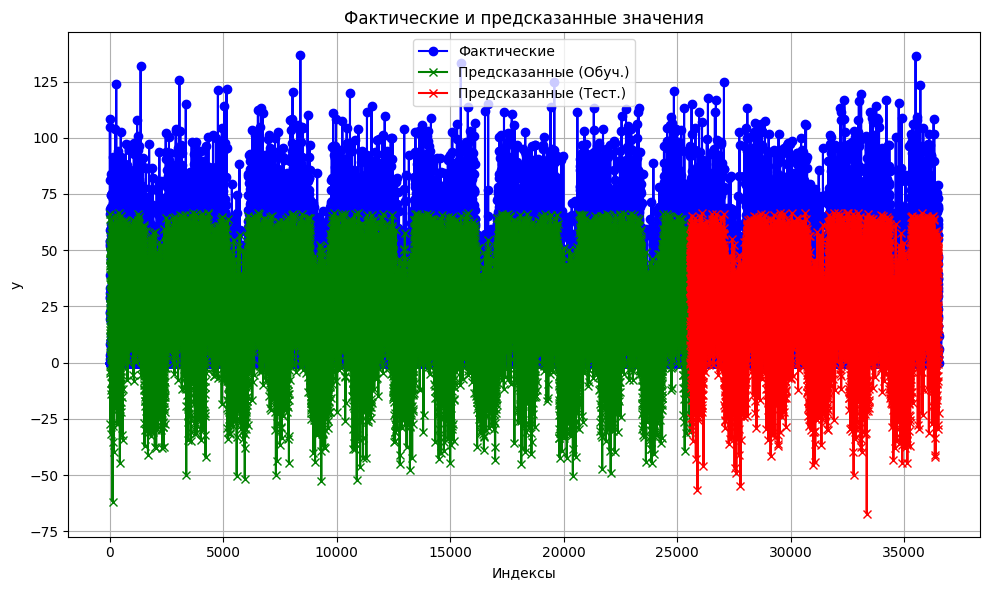

In [30]:
# Получаем предсказания
y_train_pred = lin_reg.predict(X_train)
y_test_pred = lin_reg.predict(X_test)


# Индексы для построения графика
train_indices = range(len(y_train))
test_indices = range(len(y_train), len(y_train) + len(y_test))

# Все индексы
all_indices = list(range(len(y)))
plot_actual_vs_predicted(all_indices, y, y_train_pred, y_test_pred)


In [31]:
# Создание конвейера с полиномиальными признаками и линейной регрессией
degree = 3  # Степень полинома
pipeline = make_pipeline(PolynomialFeatures(degree), LinearRegression())

# Разделение данных для временного ряда
tscv = TimeSeriesSplit(n_splits=4)

# Обучение и кросс-валидация
scores = cross_val_score(pipeline, x, y, cv=tscv, scoring='r2')
scores_rmse = cross_val_score(pipeline, x, y, cv=tscv, scoring=rmse_scorer)

print('Cross-validation RMSE:', np.mean(scores_rmse))
print('Cross-validation R²:', np.mean(scores))
print('Cross-validation RMSE:', np.mean(scores_rmse))

Cross-validation RMSE: 8.514391482974649
Cross-validation R²: 0.8910244033734463
Cross-validation RMSE: 8.514391482974649


In [32]:
# Обучение модели
pipeline.fit(X_train, y_train)

# Предсказание на тестовом наборе
y_pred = pipeline.predict(X_test)

# Оценка производительности модели
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # Корень среднеквадратичной ошибки
r2 = r2_score(y_test, y_pred)

# Вывод результатов
print('Root Mean Squared Error:', rmse)
print('R² Score:', r2)

Root Mean Squared Error: 8.541111572625395
R² Score: 0.8919664878726434


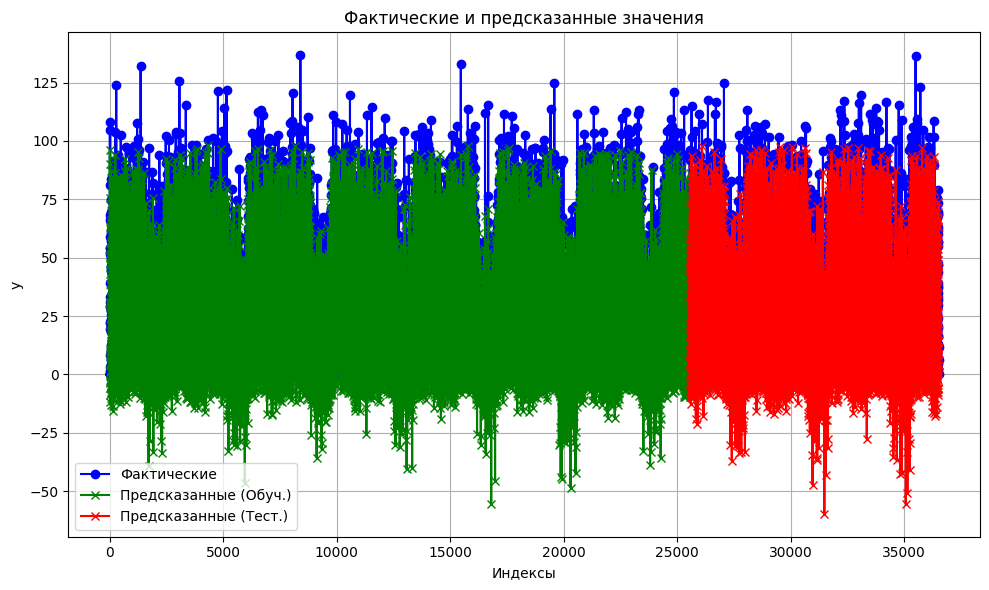

In [33]:
# Получаем предсказания
y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)


# Индексы для построения графика
train_indices = range(len(y_train))
test_indices = range(len(y_train), len(y_train) + len(y_test))

# Все индексы
all_indices = list(range(len(y)))

plot_actual_vs_predicted(all_indices, y, y_train_pred, y_test_pred)

In [34]:
las = Lasso()
rid = Ridge()

las.fit(X_train, y_train)
rid.fit(X_train, y_train)

Ridge()

In [35]:
print('Lasso R2 на обучающем :', las.score(X_train,y_train), '; на тестовом:', las.score(X_test,y_test))
scores = cross_val_score(las, x, y, cv=tscv, scoring='r2')

print('Cross-validation R²:', np.mean(scores))
scores_rmse = cross_val_score(las, x, y, cv=tscv, scoring=rmse_scorer)
print('Cross-validation RMSE:', np.mean(scores_rmse))

Lasso R2 на обучающем : 0.6457068029763506 ; на тестовом: 0.6435378523077673
Cross-validation R²: 0.6449728617618633
Cross-validation RMSE: 15.370978035113305


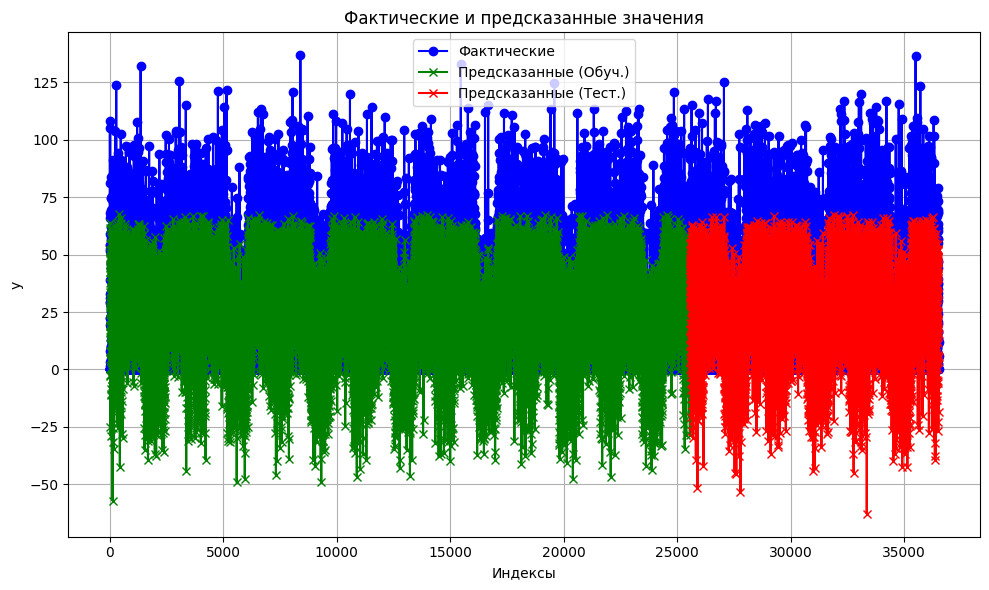

In [36]:
# Получаем предсказания
y_train_pred = las.predict(X_train)
y_test_pred = las.predict(X_test)


# Индексы для построения графика
train_indices = range(len(y_train))
test_indices = range(len(y_train), len(y_train) + len(y_test))

# Все индексы
all_indices = list(range(len(y)))
plot_actual_vs_predicted(all_indices, y, y_train_pred, y_test_pred)

In [37]:
print('Ridge R2 на обучающем :', rid.score(X_train,y_train), '; на тестовом:', rid.score(X_test,y_test))
scores = cross_val_score(rid, x, y, cv=tscv, scoring='r2')
scores_rmse = cross_val_score(rid, x, y, cv=tscv, scoring=rmse_scorer)
print('Cross-validation R²:', np.mean(scores))
print('Cross-validation RMSE:', np.mean(scores_rmse))

Ridge R2 на обучающем : 0.6484963277161366 ; на тестовом: 0.6452715341361903
Cross-validation R²: 0.6468606116450166
Cross-validation RMSE: 15.330010462741308


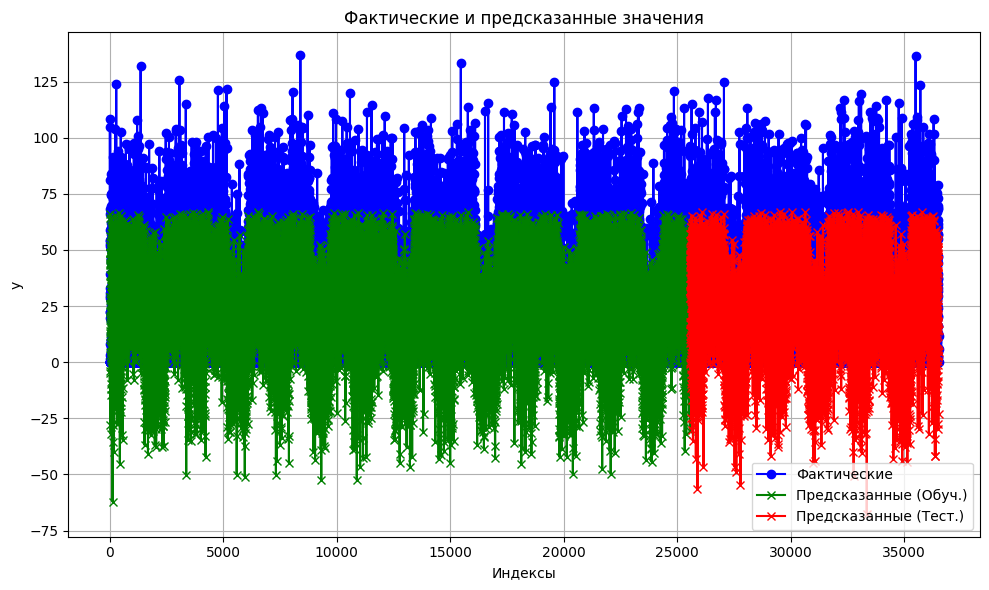

In [38]:
# Получаем предсказания
y_train_pred = rid.predict(X_train)
y_test_pred = rid.predict(X_test)


# Индексы для построения графика
train_indices = range(len(y_train))
test_indices = range(len(y_train), len(y_train) + len(y_test))

# Все индексы
all_indices = list(range(len(y)))

plot_actual_vs_predicted(all_indices, y, y_train_pred, y_test_pred)

In [39]:
pol_las = Pipeline([('poly', PolynomialFeatures(degree=4)),
                    ('regr', Lasso(alpha=0.001, max_iter=1000))])

#pol_rid = Pipeline([('poly', PolynomialFeatures(degree=3)),
#                  ('regr', Ridge(alpha=1000, max_iter=7000))])
pol_rid = Pipeline([('poly', PolynomialFeatures(degree=3)),
                   ('regr', Ridge(alpha=0.1, max_iter=100))])

In [40]:
pol_las.fit(X_train, y_train)

# Предсказание на тестовом наборе
y_pred = pol_las.predict(X_test)
# Оценка производительности модели
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # Корень среднеквадратичной ошибки
r2 = r2_score(y_test, y_pred)

# Вывод результатов
print('Root Mean Squared Error:', rmse)
print('R² Score:', r2)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.009e+06, tolerance: 1.680e+03
  model = cd_fast.enet_coordinate_descent(


Root Mean Squared Error: 9.216603339671547
R² Score: 0.8742026482140441


In [41]:
scores = cross_val_score(pol_las, x, y, cv=tscv, scoring='r2')
scores_rmse = cross_val_score(pol_las, x, y, cv=tscv, scoring=rmse_scorer)
print('Cross-validation R²:', np.mean(scores))
print('Cross-validation RMSE:', np.mean(scores_rmse))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.765e+05, tolerance: 4.752e+02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.686e+05, tolerance: 9.559e+02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.586e+05, tolerance: 1.438e

Cross-validation R²: 0.8721312255503118
Cross-validation RMSE: 9.22375748083424


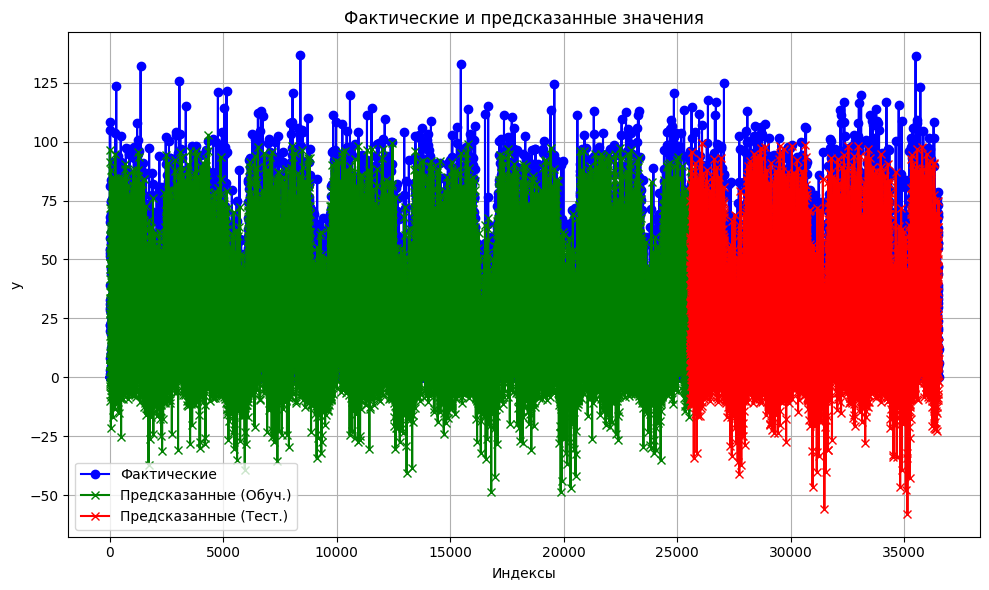

In [42]:
# Получаем предсказания
y_train_pred = pol_las.predict(X_train)
y_test_pred = pol_las.predict(X_test)


# Индексы для построения графика
train_indices = range(len(y_train))
test_indices = range(len(y_train), len(y_train) + len(y_test))

# Все индексы
all_indices = list(range(len(y)))

plot_actual_vs_predicted(all_indices, y, y_train_pred, y_test_pred)

In [43]:
pol_rid.fit(X_train, y_train)

# Предсказание на тестовом наборе
y_pred = pol_rid.predict(X_test)
# Оценка производительности модели
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # Корень среднеквадратичной ошибки
r2 = r2_score(y_test, y_pred)

# Вывод результатов
print('Root Mean Squared Error:', rmse)
print('R² Score:', r2)

Root Mean Squared Error: 8.541109602740915
R² Score: 0.8919665377053876


In [44]:
scores = cross_val_score(pol_rid, x, y, cv=tscv, scoring='r2')
scores_rmse = cross_val_score(pol_rid, x, y, cv=tscv, scoring=rmse_scorer)
print('Cross-validation R²:', np.mean(scores))
print('Cross-validation RMSE:', np.mean(scores_rmse))

Cross-validation R²: 0.8910248064018604
Cross-validation RMSE: 8.514376124520124


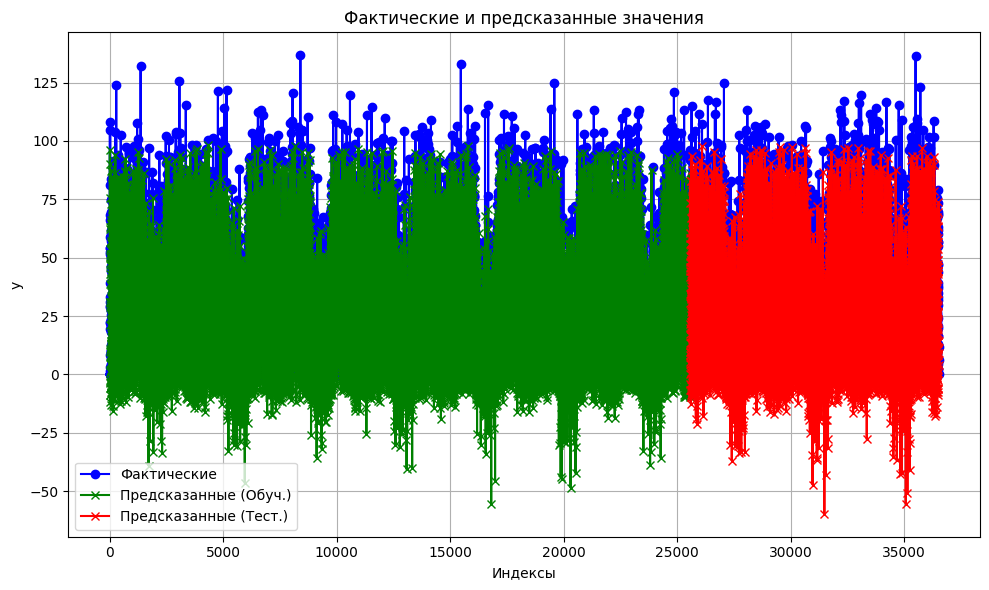

In [45]:
# Получаем предсказания
y_train_pred = pol_rid.predict(X_train)
y_test_pred = pol_rid.predict(X_test)


# Индексы для построения графика
train_indices = range(len(y_train))
test_indices = range(len(y_train), len(y_train) + len(y_test))

# Все индексы
all_indices = list(range(len(y)))

plot_actual_vs_predicted(all_indices, y, y_train_pred, y_test_pred)

In [46]:
mm_scaler = MinMaxScaler((-1,1))
std_scaler = StandardScaler()

In [47]:
#стандартизируем данные, т.к. значения в разных столбцах имеют отличающиеся порядки
X_mm_scaled = mm_scaler.fit_transform(x)
X_std_scaled = std_scaler.fit_transform(x)

In [48]:
X_train_mm_scaled, X_test_mm_scaled = X_mm_scaled[:train_size], X_mm_scaled[train_size:]
X_train_std_scaled, X_test_std_scaled = X_std_scaled[:train_size], X_std_scaled[train_size:]

In [49]:
pol_las.fit(X_train_mm_scaled, y_train)

# Предсказание на тестовом наборе
y_pred = pol_las.predict(X_test_mm_scaled)
# Оценка производительности модели
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # Корень среднеквадратичной ошибки
r2 = r2_score(y_test, y_pred)

# Вывод результатов
print('Root Mean Squared Error:', rmse)
print('R² Score:', r2)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.101e+05, tolerance: 1.680e+03
  model = cd_fast.enet_coordinate_descent(


Root Mean Squared Error: 5.418882105203581
R² Score: 0.9565140352154807


In [50]:
scores = cross_val_score(pol_las, X_mm_scaled, y, cv=tscv, scoring='r2')
scores_rmse = cross_val_score(pol_las, X_mm_scaled, y, cv=tscv, scoring=rmse_scorer)
print('Cross-validation R²:', np.mean(scores))
print('Cross-validation RMSE:', np.mean(scores_rmse))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.592e+04, tolerance: 4.752e+02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.254e+05, tolerance: 9.559e+02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.974e+05, tolerance: 1.438e

Cross-validation R²: 0.9544868611862212
Cross-validation RMSE: 5.499658019813794


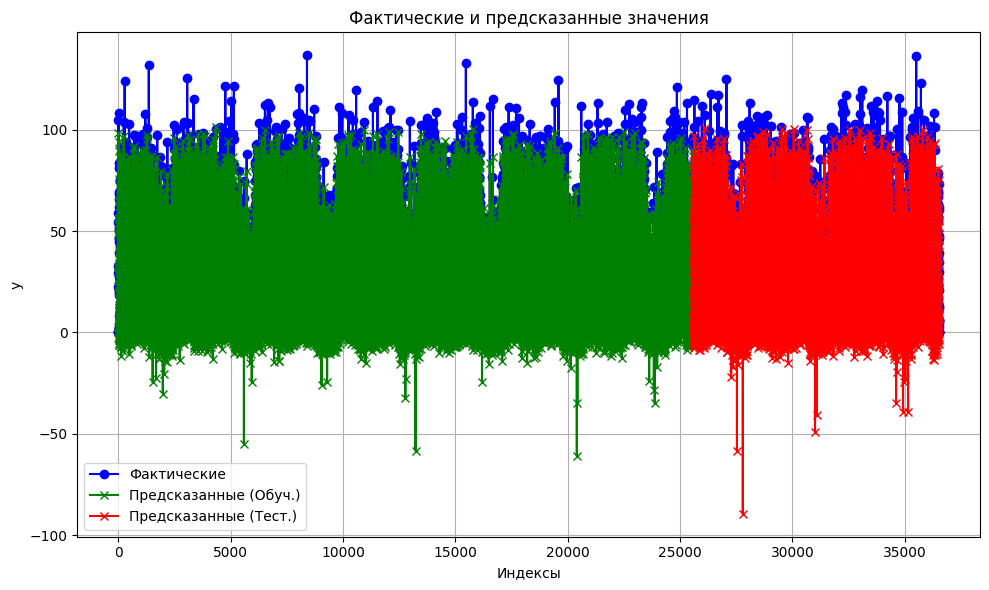

In [51]:
# Получаем предсказания
y_train_pred = pol_las.predict(X_train_mm_scaled)
y_test_pred = pol_las.predict(X_test_mm_scaled)


# Индексы для построения графика
train_indices = range(len(y_train))
test_indices = range(len(y_train), len(y_train) + len(y_test))

# Все индексы
all_indices = list(range(len(y)))

plot_actual_vs_predicted(all_indices, y, y_train_pred, y_test_pred)

In [52]:
pol_las.fit(X_train_std_scaled, y_train)

# Предсказание на тестовом наборе
y_pred = pol_las.predict(X_test_std_scaled)
# Оценка производительности модели
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # Корень среднеквадратичной ошибки
r2 = r2_score(y_test, y_pred)

# Вывод результатов
print('Root Mean Squared Error:', rmse)
print('R² Score:', r2)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.353e+05, tolerance: 1.680e+03
  model = cd_fast.enet_coordinate_descent(


Root Mean Squared Error: 5.37875120329035
R² Score: 0.9571557428404749


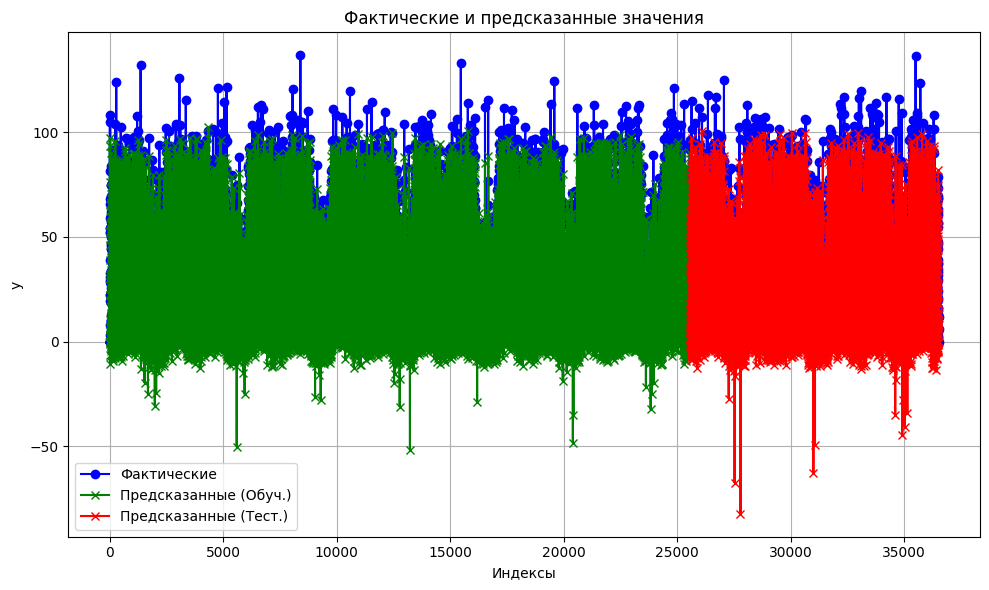

In [53]:
# Получаем предсказания
y_train_pred = pol_las.predict(X_train_std_scaled)
y_test_pred = pol_las.predict(X_test_std_scaled)


# Индексы для построения графика
train_indices = range(len(y_train))
test_indices = range(len(y_train), len(y_train) + len(y_test))

# Все индексы
all_indices = list(range(len(y)))

plot_actual_vs_predicted(all_indices, y, y_train_pred, y_test_pred)

In [54]:
scores = cross_val_score(pol_las, X_std_scaled, y, cv=tscv, scoring='r2')
scores_rmse = cross_val_score(pol_las, X_std_scaled, y, cv=tscv, scoring=rmse_scorer)
print('Cross-validation R²:', np.mean(scores))
print('Cross-validation RMSE:', np.mean(scores_rmse))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.759e+04, tolerance: 4.752e+02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.867e+05, tolerance: 9.559e+02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.865e+05, tolerance: 1.438e

Cross-validation R²: 0.9511813230650892
Cross-validation RMSE: 5.6686965333615875


In [55]:
pol_rid.fit(X_train_mm_scaled, y_train)

# Предсказание на тестовом наборе
y_pred = pol_rid.predict(X_test_mm_scaled)
# Оценка производительности модели
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # Корень среднеквадратичной ошибки
r2 = r2_score(y_test, y_pred)

# Вывод результатов
print('Root Mean Squared Error:', rmse)
print('R² Score:', r2)

Root Mean Squared Error: 8.53114411967243
R² Score: 0.8922184903474955


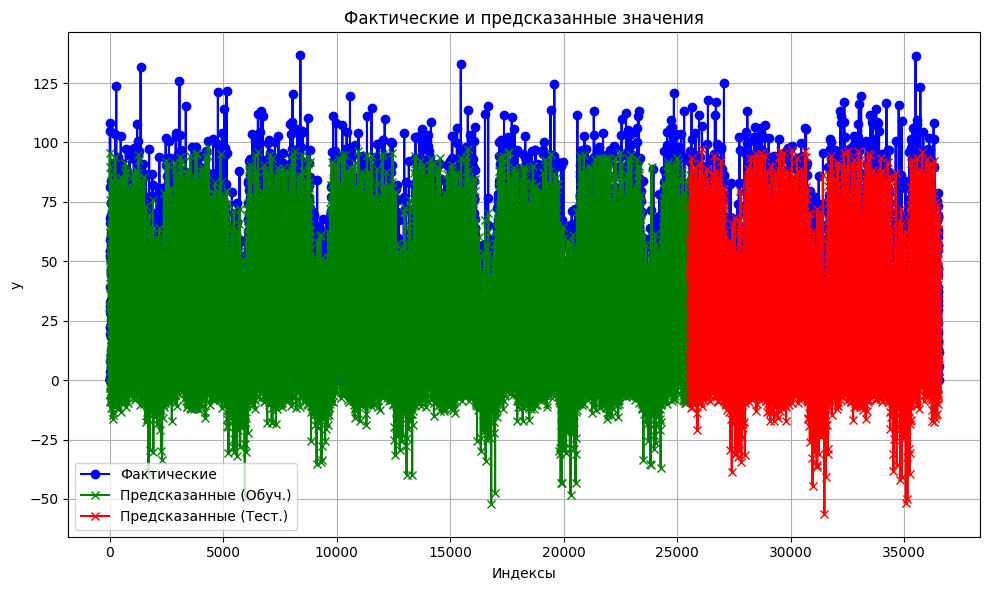

In [56]:
# Получаем предсказания
y_train_pred = pol_rid.predict(X_train_mm_scaled)
y_test_pred = pol_rid.predict(X_test_mm_scaled)


# Индексы для построения графика
train_indices = range(len(y_train))
test_indices = range(len(y_train), len(y_train) + len(y_test))

# Все индексы
all_indices = list(range(len(y)))


plot_actual_vs_predicted(all_indices, y, y_train_pred, y_test_pred)

In [57]:
scores = cross_val_score(pol_rid, X_mm_scaled, y, cv=tscv, scoring='r2')
scores_rmse = cross_val_score(pol_rid, X_mm_scaled, y, cv=tscv, scoring=rmse_scorer)
print('Cross-validation R²:', np.mean(scores))
print('Cross-validation RMSE:', np.mean(scores_rmse))

Cross-validation R²: 0.8914005365609519
Cross-validation RMSE: 8.50012913686153


In [58]:
pol_rid.fit(X_train_std_scaled, y_train)

# Предсказание на тестовом наборе
y_pred = pol_rid.predict(X_test_std_scaled)
# Оценка производительности модели
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # Корень среднеквадратичной ошибки
r2 = r2_score(y_test, y_pred)

# Вывод результатов
print('Root Mean Squared Error:', rmse)
print('R² Score:', r2)

Root Mean Squared Error: 8.538915082952977
R² Score: 0.8920220459764152


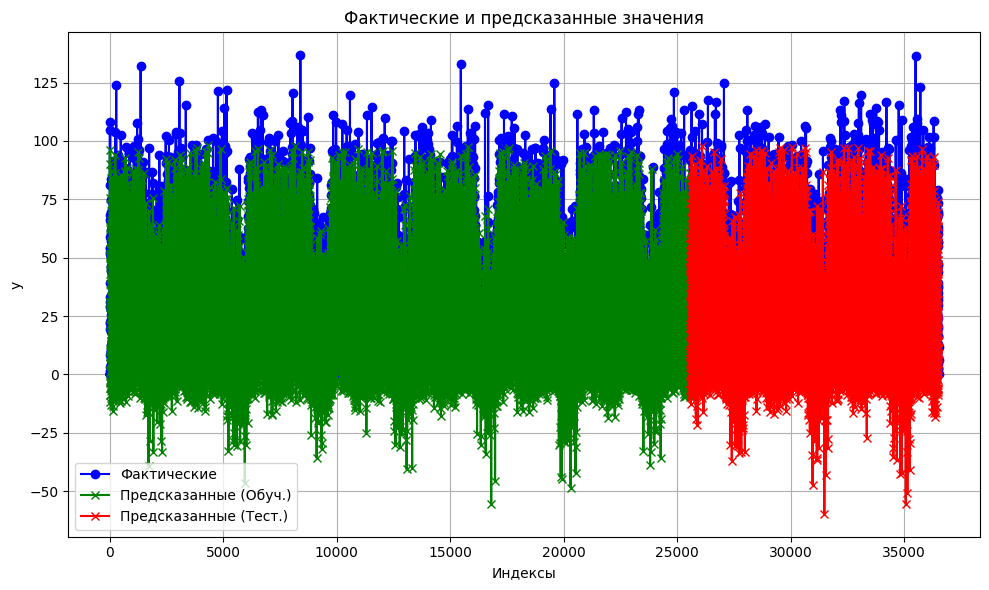

In [59]:
# Получаем предсказания
y_train_pred = pol_rid.predict(X_train_std_scaled)
y_test_pred = pol_rid.predict(X_test_std_scaled)


# Индексы для построения графика
train_indices = range(len(y_train))
test_indices = range(len(y_train), len(y_train) + len(y_test))

# Все индексы
all_indices = list(range(len(y)))


plot_actual_vs_predicted(all_indices, y, y_train_pred, y_test_pred)

In [60]:
scores = cross_val_score(pol_rid, X_std_scaled, y, cv=tscv, scoring='r2')
scores_rmse = cross_val_score(pol_rid, X_std_scaled, y, cv=tscv, scoring=rmse_scorer)
print('Cross-validation R²:', np.mean(scores))
print('Cross-validation RMSE:', np.mean(scores_rmse))

Cross-validation R²: 0.8910994850530979
Cross-validation RMSE: 8.511518699809713


In [61]:
# Используем модель градиентного бустинга (xgboost)
xgb = XGBRegressor(n_estimators=3, max_depth=8, gamma=0.2, learning_rate=0.9)

# Обучаем модель
xgb.fit(X_train, y_train)

# Оцениваем качество модели
train_score = xgb.score(X_train, y_train)
test_score = xgb.score(X_test, y_test)

# Вычисляем RMSE
y_pred = xgb.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Кросс-валидация
cv_scores = cross_val_score(xgb, x, y, cv=tscv)

print('R^2 for train set: ', train_score,
      '; for test set: ', test_score,
      '; RMSE: ', rmse,
      '; cross-validation: ', np.mean(cv_scores))

R^2 for train set:  0.9721619972100257 ; for test set:  0.9692214577985772 ; RMSE:  4.558890600358517 ; cross-validation:  0.965370495593366


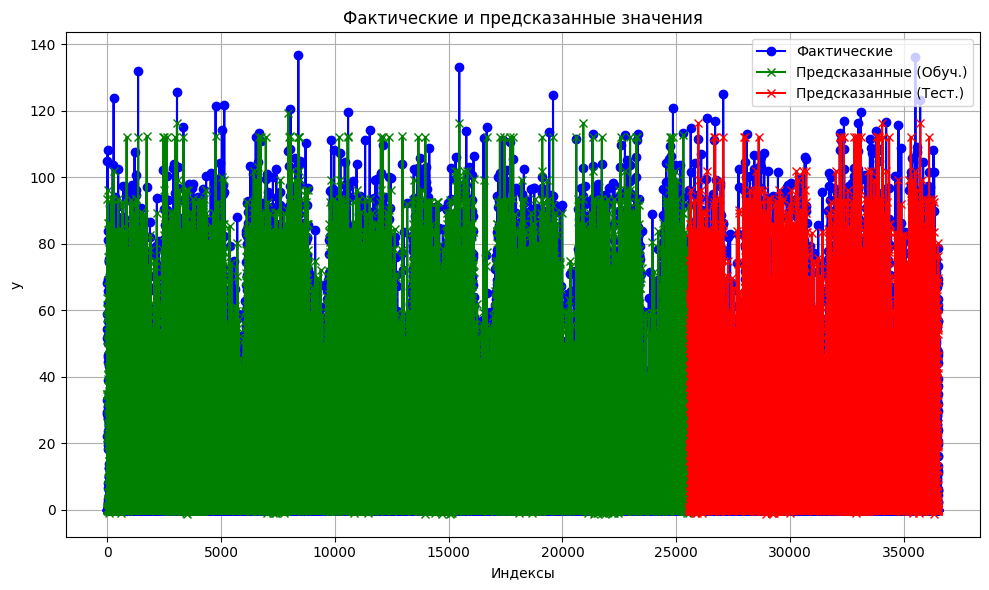

In [62]:
# Получаем предсказания
y_train_pred = xgb.predict(X_train)
y_test_pred = xgb.predict(X_test)


# Индексы для построения графика
train_indices = range(len(y_train))
test_indices = range(len(y_train), len(y_train) + len(y_test))

# Все индексы
all_indices = list(range(len(y)))


plot_actual_vs_predicted(all_indices, y, y_train_pred, y_test_pred)

<Figure size 3000x2000 with 0 Axes>

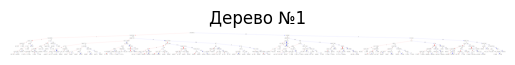

In [64]:

# Сохранение дерева в формате PDF
plt.figure(figsize=(30, 20))
plot_tree(xgb, num_trees=0)
plt.title("Дерево №1")
plt.savefig('tree1.pdf',dpi=9000)  # Сохранение в файл
plt.show()

dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.844663 to fit


<Figure size 3000x2000 with 0 Axes>

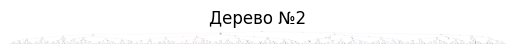

In [66]:
plt.figure(figsize=(30, 20))
plot_tree(xgb, num_trees=1)
plt.title("Дерево №2")
plt.savefig('tree2.pdf',dpi=9000)  # Сохранение в файл
plt.show()


dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.651393 to fit


<Figure size 3000x2000 with 0 Axes>

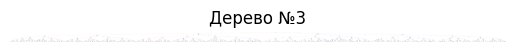

In [67]:

plt.figure(figsize=(30, 20))
plot_tree(xgb, num_trees=2)
plt.title("Дерево №3")
plt.savefig('tree3.pdf',dpi=9000)  # Сохранение в файл
plt.show()